# Lab Assignment 3 - Latent Space Classification
# Notebook 1: Train Convolutional Autoencoder

**Authors:**
- Patricia Guadalupe Alvarenga Mairena
- Francisco Manuel Vázquez Fernández

## 0. Preliminary Research

Quick notes from looking up autoencoders before starting:

- An **autoencoder** is just an encoder–decoder pair trained to reconstruct its own input. The bottleneck forces the model to keep only the most useful information about the image, so the latent vector ends up being a compact descriptor.
- For images, **convolutional** AEs are the standard choice — fully connected ones throw away spatial structure and don't scale to 96×96×3 inputs.
- The encoder downsamples (strided convs or pooling) until we reach a small spatial map, then we flatten and project to a latent vector. The decoder mirrors this with `Conv2DTranspose` to upsample back to the original size.
- Loss is usually **MSE** when pixels are in [0, 1] (with a sigmoid output) — that's what we use here. Binary crossentropy is also common but MSE is fine and easier to interpret.
- Once trained, we keep the **encoder only** and use its output as features for a downstream classifier. The idea is that 100k unlabelled images give us a much richer feature space than what a small classifier can learn from 5k labelled images.

So the plan is: train the AE on the unlabelled split (this notebook), then in notebook 2 freeze the encoder and train a small classifier on top of the latent vectors.


## 1. Import Libraries and Setup

In [ ]:
# Run this cell only on Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q tensorflow-datasets

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    # Reduces the number of warnings

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

# Configure matplotlib for inline plotting
%matplotlib inline

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("STL-10 Dataset CNN Classifier")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
# print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
# To avoid stalling due to memory problems

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

STL-10 Dataset CNN Classifier
TensorFlow version: 2.17.0
GPU Available: True


I0000 00:00:1780512052.052578     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512052.368563     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512052.368617     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 2. Configuration parameters

In [4]:
IMG_SIZE = 96  # STL-10 native size
BATCH_SIZE = 128
EPOCHS = 50
NUM_CLASSES = 10  # airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck
INITIAL_LR = 0.001
LATENT_DIM = 256  # Size of the bottleneck representation

# Class names for visualization
CLASS_NAMES = ['airplane', 'bird', 'car', 'cat', 'deer', 
               'dog', 'horse', 'monkey', 'ship', 'truck']

# Output dir — save to Drive on Colab so models persist
import sys
if 'google.colab' in sys.modules:
    SAVE_DIR = "/content/drive/MyDrive/DL_Practice_3"
    import os; os.makedirs(SAVE_DIR, exist_ok=True)
else:
    SAVE_DIR = "."

print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Initial Learning Rate: {INITIAL_LR}")
print(f"Latent Dimension: {LATENT_DIM}")
print(f"Save dir: {SAVE_DIR}")
print(f"\nClasses: {', '.join(CLASS_NAMES)}")
print(f"\nCompression ratio: {IMG_SIZE*IMG_SIZE*3} -> {LATENT_DIM} ({IMG_SIZE*IMG_SIZE*3/LATENT_DIM:.1f}x)")

Image Size: 96x96
Batch Size: 128
Epochs: 50
Number of Classes: 10
Initial Learning Rate: 0.001
Latent Dimension: 256
Save dir: .

Classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck

Compression ratio: 27648 -> 256 (108.0x)


## 3. Load STL-10 dataset

In [5]:
print("  Downloading STL-10 dataset...\n")

# Cache dataset on Google Drive so we don't re-download every session
import sys
DATA_DIR = "/content/drive/MyDrive/DL_datasets" if 'google.colab' in sys.modules else None

ds_unlabeled, ds_info = tfds.load(
    "stl10",
    split="unlabelled",
    as_supervised=False,
    with_info=True,
    data_dir=DATA_DIR
)


def ae_preprocess(example):
    image = tf.cast(example["image"], tf.float32) / 255.0
    return image, image


# NOTE: .cache() removed to avoid OOM on Colab (100k images at float32 ≈ 10.6 GB RAM)
ds_unlabeled = (
    ds_unlabeled
    .map(ae_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(5000)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

unlabelled_size = ds_info.splits['unlabelled'].num_examples

print(f"  Dataset loaded successfully!")
print(f"   Number of samples: {unlabelled_size}")
print(f"   Image shape: {ds_info.features['image'].shape}")
print(f"   Data dir: {DATA_DIR or 'default (~/.tensorflow_datasets)'}")

I0000 00:00:1780512062.653281     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512062.653336     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512062.653347     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512062.406750     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512062.406842     132 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

  Dataset loaded successfully!
   Number of samples: 100000
   Image shape: (96, 96, 3)
   Data dir: default (~/.tensorflow_datasets)


## 4. Build the Convolutional Autoencoder

We use a symmetric convolutional autoencoder. The **encoder** compresses a 96×96×3 image (27,648 values) down to a 256-dimensional latent vector — roughly a 108:1 compression ratio.

**Architecture choices:**
- **Strided convolutions** instead of MaxPooling for downsampling — this way the network learns its own downsampling filters rather than using a fixed operation.
- **Batch normalization** after each conv layer to stabilize training and allow higher learning rates.
- **ReLU activations** throughout (standard choice for deep nets).
- **Dense bottleneck** (Flatten → Dense(256)) to get a compact 1D latent vector, which makes it easy to plug into a classifier later.
- **Sigmoid output** on the decoder since our images are normalized to [0, 1].
- The decoder mirrors the encoder using `Conv2DTranspose` (transposed convolutions) to upsample back to 96×96×3.

In [6]:
def build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 3), latent_dim=LATENT_DIM):
    """Encoder: 96x96x3 -> latent_dim vector"""
    inputs = layers.Input(shape=input_shape, name="encoder_input")
    
    # Block 1: 96x96x3 -> 48x48x32
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 2: 48x48x32 -> 24x24x64
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 3: 24x24x64 -> 12x12x128
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 4: 12x12x128 -> 6x6x256
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Flatten and compress to latent vector
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent_vector")(x)
    
    encoder = models.Model(inputs, latent, name="encoder")
    return encoder

encoder = build_encoder()
encoder.summary()

Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 96, 96, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 48, 48, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 24, 24, 64)        256       
 chNormalization)                                          

In [7]:
def build_decoder(latent_dim=LATENT_DIM):
    """Decoder: latent_dim vector -> 96x96x3 image"""
    latent_input = layers.Input(shape=(latent_dim,), name="decoder_input")
    
    # Project and reshape to spatial format: 6x6x256
    x = layers.Dense(6 * 6 * 256)(latent_input)
    x = layers.ReLU()(x)
    x = layers.Reshape((6, 6, 256))(x)
    
    # Block 1: 6x6x256 -> 12x12x128
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 2: 12x12x128 -> 24x24x64
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 3: 24x24x64 -> 48x48x32
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 4: 48x48x32 -> 96x96x3 (sigmoid for [0,1] output)
    outputs = layers.Conv2DTranspose(3, 3, strides=2, padding="same", activation="sigmoid")(x)
    
    decoder = models.Model(latent_input, outputs, name="decoder")
    return decoder

decoder = build_decoder()
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 256)]             0         
                                                                 
 dense (Dense)               (None, 9216)              2368512   
                                                                 
 re_lu_4 (ReLU)              (None, 9216)              0         
                                                                 
 reshape (Reshape)           (None, 6, 6, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 12, 12, 128)       295040    
 anspose)                                                        
                                                                 
 batch_normalization_4 (Bat  (None, 12, 12, 128)       512       
 chNormalization)                                          

In [8]:
# Build the full autoencoder: encoder -> decoder
ae_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="ae_input")
latent = encoder(ae_input)
ae_output = decoder(latent)

autoencoder = models.Model(ae_input, ae_output, name="autoencoder")

print(f"Encoder:     {encoder.count_params():,} parameters")
print(f"Decoder:     {decoder.count_params():,} parameters")
print(f"Autoencoder: {autoencoder.count_params():,} parameters")
print(f"\nInput shape:  {autoencoder.input_shape}")
print(f"Output shape: {autoencoder.output_shape}")
print(f"Latent dim:   {LATENT_DIM}")

Encoder:     2,749,888 parameters
Decoder:     2,757,571 parameters
Autoencoder: 5,507,459 parameters

Input shape:  (None, 96, 96, 3)
Output shape: (None, 96, 96, 3)
Latent dim:   256


## 5. Train the Autoencoder

We compile the autoencoder with **MSE loss** — this is the standard choice for reconstruction since we want the output pixel values to match the input. Adam optimizer with a learning rate of 0.001.

**Callbacks:**
- **ReduceLROnPlateau**: if the loss stalls for 5 epochs, reduce the LR by 0.5. This helps escape plateaus without having to manually tune a schedule.
- **EarlyStopping**: stop training if the loss hasn't improved in 15 epochs. Prevents wasting time once the model has converged.

We use `steps_per_epoch` because of the `.repeat()` in the data pipeline (needed to handle corrupted samples gracefully).

In [9]:
import os

# Checkpoint path (on Drive so it survives disconnections)
CKPT_PATH = os.path.join(SAVE_DIR, "ae_checkpoint.weights.h5")

# Try to resume from checkpoint
initial_epoch = 0
if os.path.exists(CKPT_PATH):
    print(f"Found checkpoint at {CKPT_PATH}, loading weights...")
    autoencoder.load_weights(CKPT_PATH)
    # Try to figure out which epoch we were at from saved history
    if os.path.exists(os.path.join(SAVE_DIR, "ae_history.npy")):
        prev = np.load(os.path.join(SAVE_DIR, "ae_history.npy"), allow_pickle=True).item()
        initial_epoch = len(prev.get("loss", []))
        print(f"Resuming from epoch {initial_epoch}")
    else:
        print("No history found, starting epoch count from 0 with loaded weights")
else:
    print("No checkpoint found, training from scratch")

# Compile
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="mse"
)

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CKPT_PATH,
        monitor="loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=10,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    )
]

# Train
steps_per_epoch = unlabelled_size // BATCH_SIZE

print(f"\nSteps per epoch: {steps_per_epoch}")
print(f"Total samples: {unlabelled_size}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Starting from epoch: {initial_epoch}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Starting training...\n")

history = autoencoder.fit(
    ds_unlabeled,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

# Save history so we can resume later
if os.path.exists(os.path.join(SAVE_DIR, "ae_history.npy")):
    prev = np.load(os.path.join(SAVE_DIR, "ae_history.npy"), allow_pickle=True).item()
    for k in history.history:
        prev[k] = prev.get(k, []) + history.history[k]
    np.save(os.path.join(SAVE_DIR, "ae_history.npy"), prev)
    history.history = prev
else:
    np.save(os.path.join(SAVE_DIR, "ae_history.npy"), history.history)

Found checkpoint at ./ae_checkpoint.weights.h5, loading weights...
Resuming from epoch 43

Steps per epoch: 781
Total samples: 100000
Batch size: 128
Starting from epoch: 43
Checkpoint: ./ae_checkpoint.weights.h5
Starting training...

Epoch 44/50


W0000 00:00:1780512066.224177     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.232947     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.261103     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.261573     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.262284     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.263030     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.274798     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.275963     192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512066.278537     192 gp

  1/781 [..............................] - ETA: 1:03:39 - loss: 0.0084

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1780512068.641390     193 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512068.642381     193 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512068.642839     193 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512068.643216     193 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512068.643674     193 gpu_timer.cc:114] Skipping the delay kernel, measu

  2/781 [..............................] - ETA: 7:25 - loss: 0.0082   

...

723/781 [==========================>...] - ETA: 12s - loss: 0.0081
Epoch 46: loss did not improve from 0.00811
781/781 [==============================] - 25s 31ms/step - loss: 0.0081 - lr: 0.0010
Epoch 47/50
  3/781 [..............................] - ETA: 35s - loss: 0.0083

W0000 00:00:1780512164.377083     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.378658     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.379705     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.380518     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.381489     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.382178     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.382841     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.383258     195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512164.383609     195 gp

734/781 [===========================>..] - ETA: 10s - loss: 0.0081
Epoch 47: loss did not improve from 0.00811
781/781 [==============================] - 25s 32ms/step - loss: 0.0081 - lr: 0.0010
Epoch 48/50
  4/781 [..............................] - ETA: 37s - loss: 0.0080

W0000 00:00:1780512189.145277     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.145949     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.146254     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.146454     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.146673     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.146936     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.147253     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.147576     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512189.148083     190 gp

741/781 [===========================>..] - ETA: 8s - loss: 0.0081 
Epoch 48: loss did not improve from 0.00811
781/781 [==============================] - 25s 32ms/step - loss: 0.0081 - lr: 0.0010
Epoch 49/50
758/781 [============================>.] - ETA: 4s - loss: 0.0081 
Epoch 49: loss improved from 0.00811 to 0.00811, saving model to ./ae_checkpoint.weights.h5

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
781/781 [==============================] - 25s 32ms/step - loss: 0.0081 - lr: 0.0010
Epoch 50/50
763/781 [============================>.] - ETA: 3s - loss: 0.0080 
Epoch 50: loss improved from 0.00811 to 0.00797, saving model to ./ae_checkpoint.weights.h5
781/781 [==============================] - 25s 32ms/step - loss: 0.0080 - lr: 5.0000e-04
Restoring model weights from the end of the best epoch: 50.


## 6. Training Curves

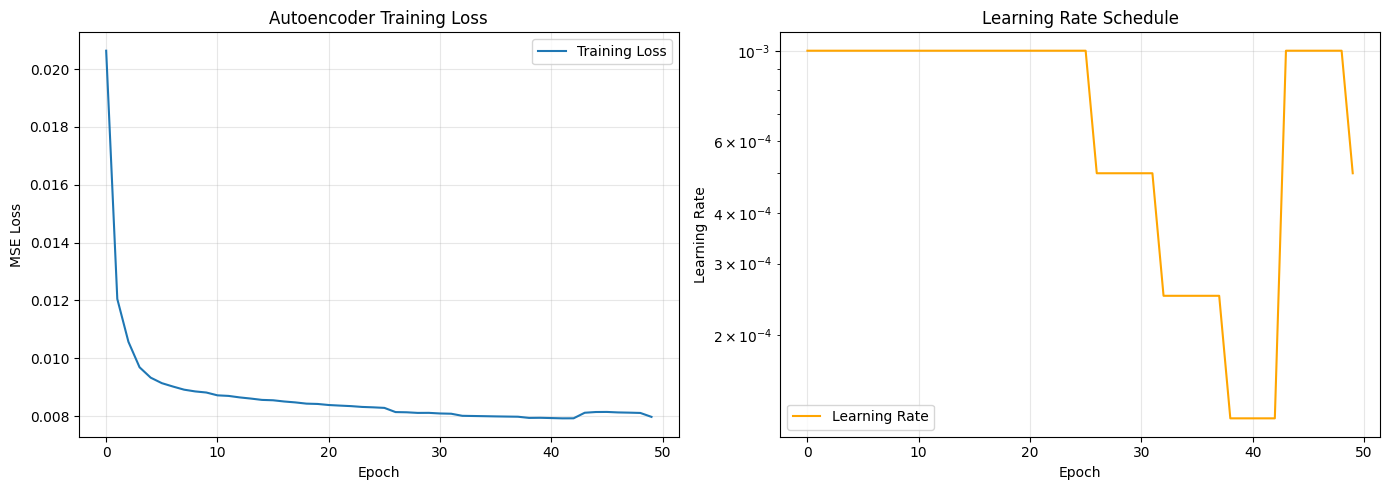


Final loss: 0.007971
Best loss:  0.007921
Epochs trained: 50
Figure saved to ./training_curves.png


In [10]:
# Load history from Drive (survives interruptions)
hist_path = os.path.join(SAVE_DIR, "ae_history.npy")
if 'history' not in dir() or not hasattr(history, 'history'):
    if os.path.exists(hist_path):
        hist_data = np.load(hist_path, allow_pickle=True).item()
        print(f"Loaded history from {hist_path} ({len(hist_data['loss'])} epochs)")
    else:
        raise FileNotFoundError(f"No history found at {hist_path}. Run training first.")
else:
    hist_data = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(hist_data["loss"], label="Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Autoencoder Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate curve
lr_key = "lr" if "lr" in hist_data else "learning_rate"
if lr_key in hist_data:
    axes[1].plot(hist_data[lr_key], label="Learning Rate", color="orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning Rate")
    axes[1].set_title("Learning Rate Schedule")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale("log")

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

print(f"\nFinal loss: {hist_data['loss'][-1]:.6f}")
print(f"Best loss:  {min(hist_data['loss']):.6f}")
print(f"Epochs trained: {len(hist_data['loss'])}")
print(f"Figure saved to {SAVE_DIR}/training_curves.png")

## 7. Visualize Reconstructions

Let's look at a few input images and their reconstructions to see how well the autoencoder learned. We don't expect pixel-perfect results with a 108:1 compression ratio, but the reconstructions should capture the overall structure and color of each image.

Loaded best weights from ./ae_checkpoint.keras


W0000 00:00:1780512265.361379     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.361891     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362048     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362184     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362312     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362464     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362699     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.362880     190 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512265.363049     190 gp

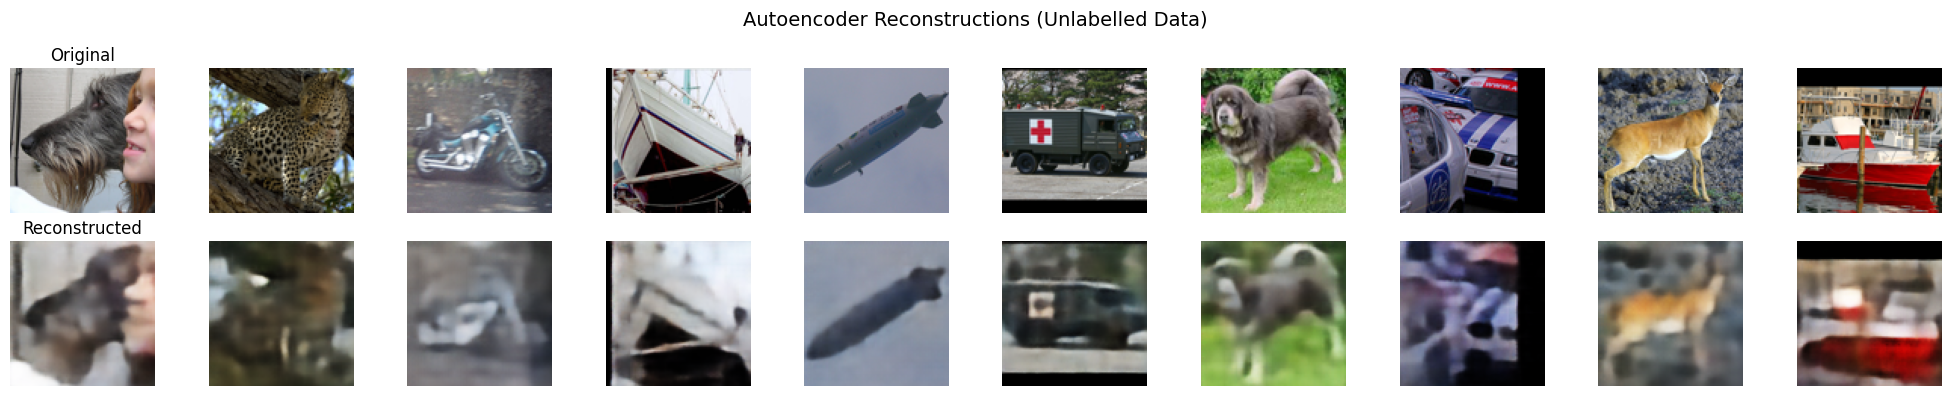

Per-image MSE: 0.008563 ± 0.003484
Figure saved to ./reconstructions.png


In [11]:
# Load checkpoint if weights were lost (e.g., after reconnection)
ckpt_path = os.path.join(SAVE_DIR, "ae_checkpoint.keras")
if os.path.exists(ckpt_path):
    autoencoder.load_weights(ckpt_path)
    print(f"Loaded best weights from {ckpt_path}")

# Grab a batch of images for visualization
sample_batch = next(iter(ds_unlabeled))
sample_images = sample_batch[0][:10]  # Take 10 images

# Get reconstructions
reconstructed = autoencoder.predict(sample_images, verbose=0)

# Plot original vs reconstructed
n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 4))

for i in range(n):
    # Original
    axes[0, i].imshow(sample_images[i].numpy())
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=12)
    
    # Reconstructed
    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=12)

plt.suptitle("Autoencoder Reconstructions (Unlabelled Data)", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "reconstructions.png"), dpi=150)
plt.show()

# Per-image MSE
per_image_mse = np.mean((sample_images.numpy() - reconstructed) ** 2, axis=(1, 2, 3))
print(f"Per-image MSE: {per_image_mse.mean():.6f} ± {per_image_mse.std():.6f}")
print(f"Figure saved to {SAVE_DIR}/reconstructions.png")

## 8. Practice 1 Dense Baseline (reproduction)

To later compare the latent-space classifier against something concrete, we re-run the **dense (FC) baseline from Practice 1** here on the labelled STL-10 splits. This gives us the test accuracy number we'll plug into notebook 2 as `P1_DENSE_BASELINE`.


In [13]:
print("Loading labelled STL-10 train and test splits...")
# Load the labelled train and test splits
ds_train_p1 = tfds.load("stl10", split="train", as_supervised=True, data_dir=DATA_DIR)
ds_test_p1  = tfds.load("stl10", split="test", as_supervised=True, data_dir=DATA_DIR)

# Preprocessing: normalize and flatten the raw pixels (96x96x3 -> 27648)
def preprocess_p1(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [-1]) # Flatten
    return image, label

ds_train_p1 = (ds_train_p1
               .map(preprocess_p1, num_parallel_calls=tf.data.AUTOTUNE)
               .cache()
               .shuffle(5000)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

ds_test_p1 = (ds_test_p1
              .map(preprocess_p1, num_parallel_calls=tf.data.AUTOTUNE)
              .cache()
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

# Build a basic Dense (FC) model from Practice 1
inputs = layers.Input(shape=(IMG_SIZE * IMG_SIZE * 3,), name="flattened_pixels")
x = layers.Dense(128, activation="relu")(inputs)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

p1_dense_model = models.Model(inputs, outputs, name="p1_dense_baseline")

p1_dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining Practice 1 Dense Baseline on raw pixels...")
# Train the model with early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    )
]

history = p1_dense_model.fit(
    ds_train_p1,
    validation_data=ds_test_p1,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on the test set
test_loss, test_acc = p1_dense_model.evaluate(ds_test_p1, verbose=0)
print(f"\n---> Actual Practice 1 Dense (FC) Test Accuracy: {test_acc:.4f} <---")


Loading labelled STL-10 train and test splits...

Training Practice 1 Dense Baseline on raw pixels...
Epoch 1/50
 1/40 [..............................] - ETA: 36s - loss: 2.3554 - accuracy: 0.1016

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


40/40 [==============================] - 2s 19ms/step - loss: 5.7797 - accuracy: 0.1594 - val_loss: 2.1173 - val_accuracy: 0.2157
Epoch 2/50
40/40 [==============================] - 1s 15ms/step - loss: 2.0737 - accuracy: 0.2376 - val_loss: 1.9923 - val_accuracy: 0.2500
Epoch 3/50
40/40 [==============================] - 1s 14ms/step - loss: 2.0824 - accuracy: 0.2196 - val_loss: 2.1068 - val_accuracy: 0.2246
Epoch 4/50
40/40 [==============================] - 1s 15ms/step - loss: 2.0316 - accuracy: 0.2360 - val_loss: 2.0577 - val_accuracy: 0.2342
Epoch 5/50
40/40 [==============================] - 1s 15ms/step - loss: 1.9985 - accuracy: 0.2554 - val_loss: 1.9863 - val_accuracy: 0.2546
Epoch 6/50
40/40 [==============================] - 1s 15ms/step - loss: 1.9627 - accuracy: 0.2644 - val_loss: 1.9846 - val_accuracy: 0.2499
Epoch 7/50
40/40 [==============================] - 1s 15ms/step - loss: 1.9557 - accuracy: 0.2574 - val_loss: 1.9995 - val_accuracy: 0.2349
Epoch 8/50
40/40 [======

## 8. Save the Encoder

We save the trained encoder so we can load it in the next notebook for latent space classification. We also save the full autoencoder in case we want to revisit it later.

In [12]:
import os
# Save models to SAVE_DIR (Drive on Colab, local otherwise)
encoder.save(os.path.join(SAVE_DIR, "encoder.keras"))
autoencoder.save(os.path.join(SAVE_DIR, "autoencoder.keras"))

print("Models saved:")
print(f"  - {SAVE_DIR}/encoder.keras")
print(f"  - {SAVE_DIR}/autoencoder.keras")
print(f"\nEncoder output shape: {encoder.output_shape}")
print("Ready to use for latent space classification in notebook 2.")

Models saved:
  - ./encoder.keras
  - ./autoencoder.keras

Encoder output shape: (None, 256)
Ready to use for latent space classification in notebook 2.


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## AI Tool Usage Declaration
We used **GitHub Copilot** (Claude-based, integrated in VS Code) as a support tool during this lab. Here is a summary of how it was used:

- **Architecture exploration**: We asked Copilot to suggest typical convolutional autoencoder designs for 96×96 images and to compare alternatives (strided convolutions vs. MaxPooling, placement of BatchNorm, sigmoid vs. tanh output activation, choice of latent dimension). We then discussed the trade-offs and selected the design we could best justify.
- **Boilerplate / Keras syntax**: Accelerating the writing of `tf.data` pipeline code, `model.fit` callbacks (`ReduceLROnPlateau`, `EarlyStopping`), and plotting code for training curves and reconstructions.
- **Debugging**: Interpreting error messages (e.g., shape mismatches between encoder output and decoder input, issues with `.repeat()` and `steps_per_epoch`).
- **Markdown explanations**: Drafting the report cells, which we then reviewed and edited to accurately reflect our own reasoning and decisions.

Every layer, hyperparameter, and regularization choice was discussed between us before being added to the notebook, and we are able to justify each one of them.

**Usefulness**: Copilot proved very helpful for speeding up repetitive tasks (boilerplate, plotting, syntax lookups) and as a brainstorming partner for design alternatives. It was less useful for the actual reasoning about *why* a given choice fits this specific dataset — that part required our own understanding of the problem.
